# NIST benchmark: MetFrag, ChemWalker, and mNAP

This notebook evaluates the three methods on the 5467 NIST tandem mass spectra used in the published ChemWalker benchmark. MetFrag supplies one shared candidate pool for every target spectrum, while ChemWalker and mNAP re-rank the same candidates using identical seed assignments.

The installed ChemWalker `cand_pair` and `random_walk` functions are executed in a separate worker process. This preserves the published implementation while providing a safe multiprocessing boundary for Windows and Jupyter. Run the cells in order after restarting the kernel.


In [1]:
from pathlib import Path
import importlib.util
import sys

# Folder containing benchmark_nist.py and chemwalker_official_worker.py
PROJECT_DIR = Path.cwd()
MODULE_PATH = PROJECT_DIR / "benchmark_nist.py"

if not MODULE_PATH.exists():
    raise FileNotFoundError(
        f"Cannot find {MODULE_PATH}. Set PROJECT_DIR to the publication-code folder."
    )

# Use an isolated module name so a previously imported copy is not reused.
MODULE_NAME = "nist_benchmark_runtime"
if MODULE_NAME in sys.modules:
    del sys.modules[MODULE_NAME]

spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
bm = importlib.util.module_from_spec(spec)
sys.modules[MODULE_NAME] = bm
assert spec.loader is not None
spec.loader.exec_module(bm)

print("Loaded module:", bm.__file__)
print("Release identifier:", bm.RELEASE_ID)
print("ChemWalker worker:", bm.CHEMWALKER_WORKER_SCRIPT)
assert bm.CHEMWALKER_WORKER_SCRIPT.name == "chemwalker_official_worker.py"
assert bm.CHEMWALKER_PARALLEL is True


Loaded module: D:\suwenyuan\Benchmark_evaluation\benchmark_nist.py
Release identifier: published_benchmark
ChemWalker worker: D:\suwenyuan\Benchmark_evaluation\chemwalker_official_worker.py


## Configure local paths

The default layout uses `data/` for the NIST MSP file, benchmark table, and PubChemLite database, `software/` for the MetFrag JAR, and `results/nist_benchmark/` for outputs. Edit these paths when the files are stored elsewhere.


In [2]:
DATA_DIR = PROJECT_DIR / "data"
SOFTWARE_DIR = PROJECT_DIR / "software"

paths = bm.configure_paths(
    input_msp=DATA_DIR / "nist.msp",
    benchmark_table=DATA_DIR / "pcbi.1006089.s007.tsv",
    pubchemlite_path=DATA_DIR / "PubChemLite.csv",
    metfrag_path=SOFTWARE_DIR / "MetFrag-CL.jar",
    output_dir=PROJECT_DIR / "results" / "nist_benchmark",
)
paths


{'INPUT_MSP': 'D:\\suwenyuan\\Benchmark_evaluation\\data\\nist.msp',
 'BENCHMARK_TABLE': 'D:\\suwenyuan\\Benchmark_evaluation\\data\\pcbi.1006089.s007.tsv',
 'PUBCHEMLITE_PATH': 'D:\\suwenyuan\\Benchmark_evaluation\\data\\PubChemLite.csv',
 'METFRAG_PATH': 'D:\\suwenyuan\\Benchmark_evaluation\\software\\MetFrag2.3-CL.jar',
 'OUT_DIR': 'D:\\suwenyuan\\Benchmark_evaluation\\results\\nist_benchmark'}

## Step 0 — validate inputs and audit the ChemWalker implementation


In [3]:
manifest = bm.run_step(0)

# These entries must refer to the installed ChemWalker package rather than
# a locally reimplemented candidate-edge or random-walk function.
manifest["chemwalker_cand_pair"], manifest["chemwalker_random_walk"]


Release identifier: published_benchmark
Python: 3.14.4 | packaged by conda-forge | (main, Apr  8 2026, 02:08:03) [MSC v.1944 64 bit (AMD64)]
Input MSP: D:\suwenyuan\Benchmark_evaluation\data\nist.msp True
Benchmark table: D:\suwenyuan\Benchmark_evaluation\data\pcbi.1006089.s007.tsv True
PubChemLite: D:\suwenyuan\Benchmark_evaluation\data\PubChemLite.csv True
MetFrag JAR: D:\suwenyuan\Benchmark_evaluation\software\MetFrag2.3-CL.jar True
Output directory: D:\suwenyuan\Benchmark_evaluation\results\nist_benchmark

Configuration:
{
  "RELEASE_ID": "published_benchmark",
  "NETWORK_CACHE_SCHEMA": "nist_network",
  "CANDIDATE_CACHE_SCHEMA": "nist_metfrag_candidates_2d",
  "SEED_ALLOCATION_SCHEME": "component_stratified_10_percent",
  "N_COMPOUNDS_TO_SAMPLE": null,
  "MAX_SPECTRA_PER_COMPOUND": 1,
  "RANDOM_SEED": 2026,
  "SEED_FRACTION": 0.1,
  "N_SEED_REPEATS": 10,
  "IONMODE_FILTER": "positive",
  "ADDUCT_FILTER": "[M+H]+",
  "SPECTRUM_TYPE_FILTER": "MS2",
  "BENCHMARK_PROCESSING_BATCH": 1,

D:\suwenyuan\Benchmark_evaluation\benchmark_nist.py:2756: UserWarning: Installed ChemWalker defaults differ from the published benchmark: sigmoid b=0.4, alpha=0.3.
  warnings.warn(


({'module': 'chemwalker.rwalker',
  'qualname': 'cand_pair',
  'signature': '(snet, tlid, method, parallel=True, meansc=True, ncors=0)',
  'source_file': 'C:\\ProgramData\\miniconda3\\envs\\chemwalker\\Lib\\site-packages\\chemwalker\\rwalker.py',
  'source_file_sha256': '536b42158ab3a61f1f076dea5027562e28a0926fb34f725d839b8e0d83669c0d',
  'callable_source_sha256': '0bd145f4c8248f260bf087bc5da8d321e422cdaa08445bb7adb4a573fc49ad77'},
 {'module': 'chemwalker.rwalker',
  'qualname': 'random_walk',
  'signature': '(graph, seed, restart_prob=0.8, step=0, epsilon=1e-06, niter=10000, sparce_matrix=True)',
  'source_file': 'C:\\ProgramData\\miniconda3\\envs\\chemwalker\\Lib\\site-packages\\chemwalker\\rwalker.py',
  'source_file_sha256': '536b42158ab3a61f1f076dea5027562e28a0926fb34f725d839b8e0d83669c0d',
  'callable_source_sha256': '7a335f67159da86b87c6003d01bd6ac4c4d61e3ab4812803909bd53c4ae25843'})

## Step 1 — read MSP and build/load the molecular network

In [4]:
# force=False reuses a checkpoint only when its input and parameter signatures match.
network = bm.run_step(1, force=False)
network["component_sizes"].head(10)


Step 1A. Read MSP and align it to the published benchmark table
Raw MSP records: 555
Benchmark rows for batch 1 : 540
Loaded aligned spectra: 555
Unique 2D structures: 540
Skipped records: {'not_ms2': 0, 'not_m_plus_h': 0, 'not_positive': 0, 'too_few_peaks': 0, 'missing_key': 0, 'missing_truth': 0, 'missing_structure': 0, 'missing_precursor': 0}

Step 1B. Select one representative spectrum per 2D structure

Step 1C. Deterministic benchmark sampling
Sampled spectra: 540
Sampled compounds: 540

Step 1D. Build modified-cosine molecular network
Using scorer: ModifiedCosineGreedy (matchms 0.33.1)
Pairing 0/540
Pairing 100/540
Pairing 200/540
Pairing 300/540
Pairing 400/540
Pairing 500/540
Raw edges: (1531, 7)
Mutual TopK edges: (1017, 7)
Network nodes: 435
Network edges: 1017
Connected components: 61


,ComponentIndex,n_nodes,n_edges
0,1,164,494
1,2,32,119
2,3,25,76
3,4,21,68
4,5,14,42
5,6,12,48
7,8,9,21
6,7,9,12
8,9,7,8
9,10,6,11


Saved Step 1 checkpoint: D:\suwenyuan\Benchmark_evaluation\results\nist_benchmark\checkpoints\step1_network.pkl


,ComponentIndex,n_nodes,n_edges
0,1,164,494
1,2,32,119
2,3,25,76
3,4,21,68
4,5,14,42
5,6,12,48
7,8,9,21
6,7,9,12
8,9,7,8
9,10,6,11


## Step 2A — validate MetFrag Score parsing on five nodes


In [5]:
# This audit checks the official MetFrag Score field and does not overwrite
# the complete Step 2 candidate checkpoint.
test_candidates = bm.run_step(2, force=True, max_nodes=5)
test_candidates[["node_id", "Identifier", "Score", "score_source", "InChIKey1"]].head(20)


Loaded Step 1 checkpoint: D:\suwenyuan\Benchmark_evaluation\results\nist_benchmark\checkpoints\step1_network.pkl
Network signature: 0131eec38457
Network nodes: 435
Network edges: 1017
Raw DB shape: (570077, 37)
Raw DB columns: ['Identifier', 'FirstBlock', 'PubMed_Count', 'Patent_Count', 'Related_CIDs', 'Synonym', 'MolecularFormula', 'SMILES', 'InChI', 'InChIKey1', 'InChIKey2', 'MonoisotopicMass', 'XLogP', 'CompoundName', 'AnnoTypeCount', 'AgroChemInfo', 'BioPathway', 'DrugMedicInfo', 'FoodRelated', 'PharmacoInfo', 'SafetyInfo', 'ToxicityInfo', 'KnownUse', 'DisorderDisease', 'Identification', 'ChemClass', 'pred_CCS_A2_[M+H]+', 'pred_CCS_A2_[M+Na]+', 'pred_CCS_A2_[M-H]-', 'pred_CCS_A2_[M+NH4]+', 'pred_CCS_A2_[M+K]+', 'pred_CCS_A2_[M+H-H2O]+', 'pred_CCS_A2_[M+HCOO]-', 'pred_CCS_A2_[M+CH3COO]-', 'pred_CCS_A2_[M+Na-2H]-', 'pred_CCS_A2_[M]+', 'pred_CCS_A2_[M]-']
Standardized DB shape: (570077, 9)
MetFrag node 1/5: node_id=5

MetFrag score verification for node 5
Raw columns: ['Score', 'InChI

,node_id,Identifier,Score,score_source,InChIKey1
0,5,101647,0.0,Score column,IZKWCZBXYUWECV
1,5,10607526,0.0,Score column,PJYIGONWNQJLJK
2,5,10986946,0.0,Score column,JTMODJXOTWYBOZ
3,5,11098,0.0,Score column,DYFFAVRFJWYYQO
4,5,112692724,0.0,Score column,XTIZZBWUKPANHA
5,5,11644036,0.0,Score column,ZOIHWNNIRAGRNZ
6,5,119805,0.0,Score column,DWOBGCPUQNFAFB
7,5,1207241,0.0,Score column,JISVTVYXQCPMEN
8,5,12109,0.0,Score column,AGHYMXKKEXDUTA
9,5,12246986,0.0,Score column,CARILLOXVAEKID


## Step 2B — generate or load the shared MetFrag candidate lists


In [6]:
# Parameter-compatible candidate caches are reused when their signatures match.
all_candidates = bm.run_step(2, force=False)
print("Candidate rows:", len(all_candidates))
print("Nodes with candidates:", all_candidates["node_id"].nunique())


Loaded Step 1 checkpoint: D:\suwenyuan\Benchmark_evaluation\results\nist_benchmark\checkpoints\step1_network.pkl
Network signature: 0131eec38457
Network nodes: 435
Network edges: 1017
Raw DB shape: (570077, 37)
Raw DB columns: ['Identifier', 'FirstBlock', 'PubMed_Count', 'Patent_Count', 'Related_CIDs', 'Synonym', 'MolecularFormula', 'SMILES', 'InChI', 'InChIKey1', 'InChIKey2', 'MonoisotopicMass', 'XLogP', 'CompoundName', 'AnnoTypeCount', 'AgroChemInfo', 'BioPathway', 'DrugMedicInfo', 'FoodRelated', 'PharmacoInfo', 'SafetyInfo', 'ToxicityInfo', 'KnownUse', 'DisorderDisease', 'Identification', 'ChemClass', 'pred_CCS_A2_[M+H]+', 'pred_CCS_A2_[M+Na]+', 'pred_CCS_A2_[M-H]-', 'pred_CCS_A2_[M+NH4]+', 'pred_CCS_A2_[M+K]+', 'pred_CCS_A2_[M+H-H2O]+', 'pred_CCS_A2_[M+HCOO]-', 'pred_CCS_A2_[M+CH3COO]-', 'pred_CCS_A2_[M+Na-2H]-', 'pred_CCS_A2_[M]+', 'pred_CCS_A2_[M]-']
Standardized DB shape: (570077, 9)
MetFrag node 1/435: node_id=5

MetFrag score verification for node 15
Raw columns: ['Score', 'In

## Step 3A — smoke-test ChemWalker on a small component

Use a small connected component for the first execution check. Partial results are written under `smoke_tests/` and do not overwrite the complete benchmark results.


In [7]:
smoke_component = bm.choose_smoke_component(max_nodes=10)
print("Selected smoke-test component:", smoke_component)

smoke = bm.run_step(
    3,
    repeat_ids=[0],
    component_ids=[smoke_component],
    force=True,
)
smoke.head()

Loaded Step 1 checkpoint: D:\suwenyuan\Benchmark_evaluation\results\nist_benchmark\checkpoints\step1_network.pkl
Network signature: 0131eec38457
Network nodes: 435
Network edges: 1017
Selected smoke-test component: 33
Loaded Step 1 checkpoint: D:\suwenyuan\Benchmark_evaluation\results\nist_benchmark\checkpoints\step1_network.pkl
Network signature: 0131eec38457
Network nodes: 435
Network edges: 1017
Partial/smoke run: formal repeat result files will not be overwritten. Selected components: [33]

Seed repeat 0
split
target    349
seed       86
Name: count, dtype: int64
Repeat 0; component 1/1; component_id=33; nodes=2; edges=1
Original ChemWalker worker started: repeat=0, component=33, spectral_edges=1, tlid_rows=51, estimated_candidate_pairs=50, cores=4
Worker log: D:\suwenyuan\Benchmark_evaluation\results\nist_benchmark\chemwalker_worker\06835609f364\repeat_000\component_0033\worker.log
Original ChemWalker completed: component=33; elapsed=0.1 min; candidate_edges=50
Combined benchmark 

,repeat_id,component_id,target_node,target_name,true_inchikey1,n_component_nodes,n_component_seeds,n_component_edges,n_target_candidates,true_candidate_found,MetFrag_rank,ChemWalker_rank,mNAP_rank,ChemWalker_reachable,mNAP_reachable,ChemWalker_fingerprint,ChemWalker_execution,ChemWalker_candidate_edges,ChemWalker_estimated_candidate_pairs,ChemWalker_seconds
0,0,33,33,(+)-Methamphetamine,MYWUZJCMWCOHBA,2,1,1,50,True,1.0,2.0,2.0,True,True,MFP2-bits,official_parallel_subprocess,50,50,2.823084


## Step 3B — run the first seed allocation across all components

For each spectral edge, the original `cand_pair` function evaluates the Cartesian product of candidate structures from the two connected spectra. Large components can therefore require substantially more computation. Worker progress and log locations are printed during execution.


In [ ]:
repeat0 = bm.run_step(
    3,
    repeat_ids=[0],
    component_ids=None,
    force=False,
)
repeat0.head()

## Step 3C — run or load all configured seed allocations


In [8]:
all_results = bm.run_step(
    3,
    repeat_ids=None,
    component_ids=None,
    force=False,
)
print(all_results.shape)

Loaded Step 1 checkpoint: D:\suwenyuan\Benchmark_evaluation\results\nist_benchmark\checkpoints\step1_network.pkl
Network signature: 0131eec38457
Network nodes: 435
Network edges: 1017

Seed repeat 0
split
target    349
seed       86
Name: count, dtype: int64
Repeat 0; component 1/61; component_id=1; nodes=164; edges=494
Original ChemWalker worker started: repeat=0, component=1, spectral_edges=490, tlid_rows=5,732, estimated_candidate_pairs=627,063, cores=4
Worker log: D:\suwenyuan\Benchmark_evaluation\results\nist_benchmark\chemwalker_worker\06835609f364\repeat_000\component_0001\worker.log
  original ChemWalker still running; elapsed=0.5 min; component=1; candidate_pairs=627,063
  original ChemWalker still running; elapsed=1.0 min; component=1; candidate_pairs=627,063
  original ChemWalker still running; elapsed=1.5 min; component=1; candidate_pairs=627,063
  original ChemWalker still running; elapsed=2.0 min; component=1; candidate_pairs=627,063
  original ChemWalker still running; e

## Step 4 — evaluate fixed-denominator performance and generate figures



Fixed-denominator summary:


,method,n_total,n_ranked,ranking_coverage,Top1,Top5,Top10,Top20,MRR_fixed_denominator,mean_penalized_rank,median_penalized_rank,mean_rank_among_ranked,median_rank_among_ranked
0,ChemWalker,197,197,1.0,0.385787,0.690355,0.796954,0.903553,0.532029,6.573604,2.0,6.573604,2.0
1,MetFrag,197,197,1.0,0.248731,0.553299,0.690355,0.857868,0.387005,8.832487,5.0,8.832487,5.0
2,mNAP,197,197,1.0,0.385787,0.730964,0.837563,0.903553,0.542696,6.203046,2.0,6.203046,2.0



Pairwise statistics across all seed repeats (descriptive):


,comparison,n_fixed_denominator,ChemWalker_Top10_only,MetFrag_Top10_only,both_success,neither_success,paired_exact_p,n_common_finite_rank,ChemWalker_better_rank,MetFrag_better_rank,rank_tie,mean_rank_delta_ChemWalker_minus_MetFrag,wilcoxon_p,mNAP_Top10_only,mNAP_better_rank,mean_rank_delta_mNAP_minus_MetFrag,mean_rank_delta_mNAP_minus_ChemWalker,analysis_scope
0,ChemWalker vs MetFrag,197,27.0,6.0,130,34,0.000324,197,92.0,45.0,60,-2.258883,0.000008,NaN,NaN,NaN,NaN,all seed repeats; descriptive paired instances
1,mNAP vs MetFrag,197,NaN,6.0,130,26,0.000005,197,NaN,50.0,48,NaN,0.000005,35.0,99.0,-2.629442,NaN,all seed repeats; descriptive paired instances
2,mNAP vs ChemWalker,197,1.0,NaN,156,31,0.021484,197,44.0,NaN,96,NaN,0.104157,9.0,57.0,NaN,-0.370558,all seed repeats; descriptive paired instances


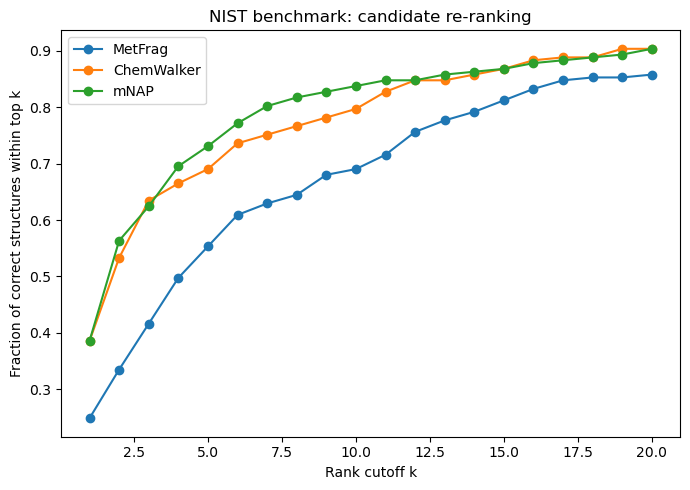

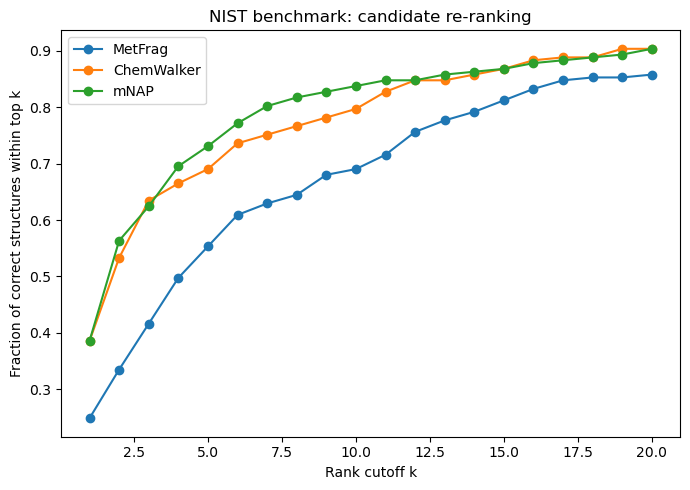


Candidate coverage:


,n_unique_target_nodes,n_unique_targets_with_true_candidate,candidate_coverage,candidate_cap,mass_tolerance_ppm
0,349,197,0.56447,50,10



Outputs saved to: D:\suwenyuan\Benchmark_evaluation\results\nist_benchmark


,method,n_total,n_ranked,ranking_coverage,Top1,Top5,Top10,Top20,MRR_fixed_denominator,mean_penalized_rank,median_penalized_rank,mean_rank_among_ranked,median_rank_among_ranked
0,ChemWalker,197,197,1.0,0.385787,0.690355,0.796954,0.903553,0.532029,6.573604,2.0,6.573604,2.0
1,MetFrag,197,197,1.0,0.248731,0.553299,0.690355,0.857868,0.387005,8.832487,5.0,8.832487,5.0
2,mNAP,197,197,1.0,0.385787,0.730964,0.837563,0.903553,0.542696,6.203046,2.0,6.203046,2.0


In [9]:
outputs = bm.run_step(4)
outputs["summary"]

In [ ]:
outputs["pairwise_first_repeat"]

In [ ]:
outputs["bootstrap"]

## Optional diagnostics

Per-component ChemWalker logs and audit records are stored under:

```text
<output_dir>/chemwalker_worker/<ranking_signature>/repeat_000/component_XXXX/
```

Each `audit.json` records source hashes for the installed `cand_pair` and `random_walk` functions, the candidate-pair count, candidate-graph size, seed coverage, and execution time.
